# Detection d'anomalies salariales par Machine Learning (approche non supervisee)

Objectif : a partir des **3 fichiers de donnees bruts** (`input/employes.csv`, `input/market.csv`,
`input/bands.csv`), reconstruire les memes indicateurs de comparaison marche que le moteur de regles
existant (`src/anomaly_core.py`) puis detecter les anomalies salariales avec des **modeles ML non
supervises** (IsolationForest, Local Outlier Factor, One-Class SVM) : on ne dispose ici d'aucune
etiquette "Severity" prete a l'emploi (elle n'existe que dans `anomalies.csv`, produit par le moteur
de regles), donc il ne s'agit pas de reproduire un score de regles mais de laisser des algorithmes de
detection d'outliers trouver eux-memes les profils atypiques.

Plan :
1. Chargement des 3 fichiers bruts
2. Feature engineering (reprise des fonctions deja testees de `anomaly_core.py` : CompaRatio,
   RangePenetration, MarketRatio, statistiques de cohorte, PeerZ) - **sans** reprendre la partie
   "regles"/scoring du fichier
3. Analyse exploratoire (EDA) des features obtenues
4. Detection d'anomalies non supervisee (3 algorithmes compares)
5. Consensus multi-modeles et visualisation des anomalies detectees
6. Classification interpretable : un modele supervise (Random Forest) est entraine sur les labels
   produits par la detection non supervisee, pour en tirer une **feature importance** claire
7. Sauvegarde des resultats et du modele


## 1. Chargement des donnees brutes

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

# Les fonctions de feature engineering (deja ecrites et testees dans le projet) vivent dans
# src/anomaly_core.py. On les reutilise plutot que de reecrire des formules qui existent deja.
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "src" / "anomaly_core.py").is_file())
sys.path.insert(0, str(ROOT / "src"))
MODEL_DIR = ROOT / "models"
OUTPUT_DIR = ROOT / "output" / "classification"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
from anomaly_core import bucket_anciennete, compute_features, apply_rulebook, cohort_stats_and_peers_nv

In [2]:
employees = pd.read_csv(ROOT / "input" / "employes.csv", sep=";", encoding="cp1252")
market = pd.read_csv(ROOT / "input" / "market.csv", sep=";", encoding="cp1252")
bands = pd.read_csv(ROOT / "input" / "bands.csv", sep=";", encoding="cp1252")

print("employes :", employees.shape)
print("market   :", market.shape)
print("bands    :", bands.shape)
employees.head()

employes : (10000, 18)
market   : (91, 7)
bands    : (91, 7)


,Matricule,Nom,Entite_N1,Entite_N2,Pays,Job_Family,Job_Title,Grade,Fixe_Annuel_MAD,Age,Anciennete,Sexe,FTE,Devise,Date_Effet_Paie,Competence_N1,Positionnement_9BOX,Hot_job
0,Mat00001,NaN,Pole 3,P3-E14,Maroc,RETAIL BANKING,Chef de Projet Reseau Agences,5,191.80,34,6,M,1,MAD,01/08/2025,4.29,4,1
1,Mat00002,NaN,Pole 3,P3-E17,Maroc,RETAIL BANKING,Manager Clientele Particuliers,3,584.00,37,8,M,1,MAD,01/08/2025,3.93,3,0
2,Mat00003,NaN,Pole 3,P3-E14,Maroc,RETAIL BANKING,Directeur Adjoint Clientele Professionnels,2,506.15,37,10,M,1,MAD,01/08/2025,2.94,6,0
3,Mat00004,NaN,Pole 4,P4-E13,Maroc,FINANCE,Chef de Projet Senior Controle de Gestion,4,351.26,44,4,M,1,MAD,01/08/2025,2.91,5,0
4,Mat00005,NaN,Pole 4,P4-E08,Maroc,IT,Charge Developpement Applicatif,6,173.16,43,0,M,1,MAD,01/08/2025,2.86,2,0


In [3]:
employees.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Matricule            10000 non-null  object 
 1   Nom                  0 non-null      float64
 2   Entite_N1            10000 non-null  object 
 3   Entite_N2            10000 non-null  object 
 4   Pays                 10000 non-null  object 
 5   Job_Family           10000 non-null  object 
 6   Job_Title            10000 non-null  object 
 7   Grade                10000 non-null  int64  
 8   Fixe_Annuel_MAD      10000 non-null  float64
 9   Age                  10000 non-null  int64  
 10  Anciennete           10000 non-null  int64  
 11  Sexe                 10000 non-null  object 
 12  FTE                  10000 non-null  int64  
 13  Devise               10000 non-null  object 
 14  Date_Effet_Paie      10000 non-null  object 
 15  Competence_N1        10000 non-null  

## 2. Feature engineering

On reutilise `compute_features` (jointure avec `bands`/`market` sur `Job_Family`+`Grade`, calcul de
`CompaRatio`, `RangePenetration`, `MarketRatio`) et `cohort_stats_and_peers_nv` (statistiques de
cohorte + `PeerZ`, le z-score robuste vis-a-vis des pairs) de `anomaly_core.py`. `cohort_stats_and_peers_nv`
suppose que `Rule_Flags`/`Rule_Score` existent deja (normalement remplis par `apply_rulebook`) : on
appelle donc aussi `apply_rulebook` par simple dependance technique, puis on **supprime immediatement**
tout ce qui releve du scoring de regles (`Rule_Flags`, `Rule_Score`, `Reason_Principale`, `Peer_Flag`).
On ne reprend en revanche ni `aggregate_risk`, ni le `ml_anomaly` (IsolationForest) deja present dans ce
fichier : c'est precisement cette derniere etape qu'on refait nous-memes ci-dessous, en comparant
plusieurs algorithmes.

In [4]:
df = compute_features(employees.copy(), bands, market)
df = apply_rulebook(df, rule_params={})
df = cohort_stats_and_peers_nv(df, rule_params={})

# Colonnes de scoring/regles (necessaires uniquement en interne a cohort_stats_and_peers_nv) :
# on les supprime, on ne garde que les statistiques de cohorte et le PeerZ, qui sont de simples
# features de comparaison, pas un verdict.
df = df.drop(columns=["Rule_Flags", "Rule_Score", "Peer_Flag", "Reason_Principale"], errors="ignore")

print(df.shape)
df[["Matricule", "Job_Family", "Grade", "Fixe_Annuel_MAD", "Min", "Mid", "Max", "Market_Median",
    "CompaRatio", "RangePenetration", "MarketRatio", "Cohort_Size", "PeerZ"]].head(10)

(10000, 34)


,Matricule,Job_Family,Grade,Fixe_Annuel_MAD,Min,Mid,Max,Market_Median,CompaRatio,RangePenetration,MarketRatio,Cohort_Size,PeerZ
0,Mat00001,RETAIL BANKING,5,191.80,131.91,196.88,261.84,196.88,0.974197,0.460941,0.974197,448,-0.240828
1,Mat00002,RETAIL BANKING,3,584.00,206.10,307.62,409.13,307.62,1.898446,1.861301,1.898446,235,3.688605
2,Mat00003,RETAIL BANKING,2,506.15,257.63,384.52,511.41,384.52,1.316316,0.979273,1.316316,157,1.344178
3,Mat00004,FINANCE,4,351.26,185.47,276.82,368.17,276.82,1.268911,0.907444,1.268911,57,1.066360
4,Mat00005,IT,6,173.16,167.50,250.00,332.50,250.00,0.692640,0.034303,0.692640,75,-1.220912
5,Mat00006,TRANSFORMATION,5,178.60,131.91,196.88,261.84,196.88,0.907152,0.359347,0.907152,16,-0.296921
6,Mat00007,FINANCE,7,116.77,84.42,126.00,167.58,126.00,0.926746,0.389009,0.926746,48,-0.186222
7,Mat00008,RETAIL BANKING,6,178.04,105.53,157.50,209.48,157.50,1.130413,0.697547,1.130413,420,0.563136
8,Mat00009,TRANSFORMATION,6,196.94,105.53,157.50,209.48,157.50,1.250413,0.879365,1.250413,17,1.464079
9,Mat00010,RETAIL BANKING,5,158.85,131.91,196.88,261.84,196.88,0.806837,0.207342,0.806837,322,-0.861543


**Lecture du tableau ci-dessus.** La jointure a fonctionné : chaque employé a bien recu son `Min`/`Mid`/`Max` (bande interne) et son `Market_Median`. On remarque tout de suite que `CompaRatio` et `MarketRatio` sont **identiques** ligne par ligne (0.974197 / 0.974197, 1.898446 / 1.898446, ...) : ce n'est pas une coïncidence, c'est parce que dans ce jeu de données `bands.csv.Mid` est **rigoureusement égal** à `market.csv.Median` pour chaque combinaison `Job_Family`/`Grade` (vérifié : 100% des 91 lignes). Autrement dit, la "fourchette interne" et le "marché externe" racontent ici exactement la même histoire. Implication pour la suite : `CompaRatio` et `MarketRatio` n'apportent **aucune information supplémentaire l'une par rapport à l'autre** dans ce dataset (ce sera confirmé par une corrélation de 1.00 dans la matrice de corrélation plus bas) — dans un vrai jeu de données RH, ces deux ratios divergent generalement.

In [5]:
missing = df.isna().sum()
missing[missing > 0].sort_values(ascending=False)

Nom    10000
dtype: int64

**Interprétation.** Seule `Nom` est vide (10000/10000) — c'est normal, ce champ n'a jamais été renseigné dans `employes.csv` et n'est pas utilisé. Aucune valeur manquante sur `CompaRatio`/`RangePenetration`/`MarketRatio`/`PeerZ` : cela **confirme que la jointure avec `bands`/`market` a réussi pour tous les employés**, donc que chaque combinaison `Job_Family`+`Grade` présente chez les employés existe bien dans `bands.csv` et `market.csv`.

In [6]:
# Employes sans correspondance de bande/marche (Job_Family/Grade absent de bands ou market) :
# leurs ratios sont NaN et fausseraient l'entrainement ML. On les met de cote et on travaille sur
# le reste, qui couvre la grande majorite des effectifs.
before = len(df)
df = df.dropna(subset=["CompaRatio", "RangePenetration", "MarketRatio", "PeerZ"]).copy()
print(f"{before - len(df)} ligne(s) ecartee(s) faute de correspondance bande/marche -> {len(df)} lignes conservees")

0 ligne(s) ecartee(s) faute de correspondance bande/marche -> 10000 lignes conservees


**Interprétation.** `0 ligne(s) écartée(s)` : les 91 combinaisons `Job_Family`×`Grade` de `bands.csv`/`market.csv` couvrent bien la totalité des 10 000 employés de `employes.csv`. Rien n'a été perdu — on travaille sur la population complète pour toute la suite du notebook.

## 3. Analyse exploratoire (EDA)

**Objectif de ce graphe.** Verifier a quoi ressemble la variable la plus brute, le salaire (`Fixe_Annuel_MAD`) : est-elle tres etalee/asymetrique (justifiant une echelle log) ? Et est-ce que le niveau de salaire varie beaucoup d'un `Job_Family` a l'autre (justifiant de comparer chaque employe a son propre metier plutot qu'a la population entiere) ?

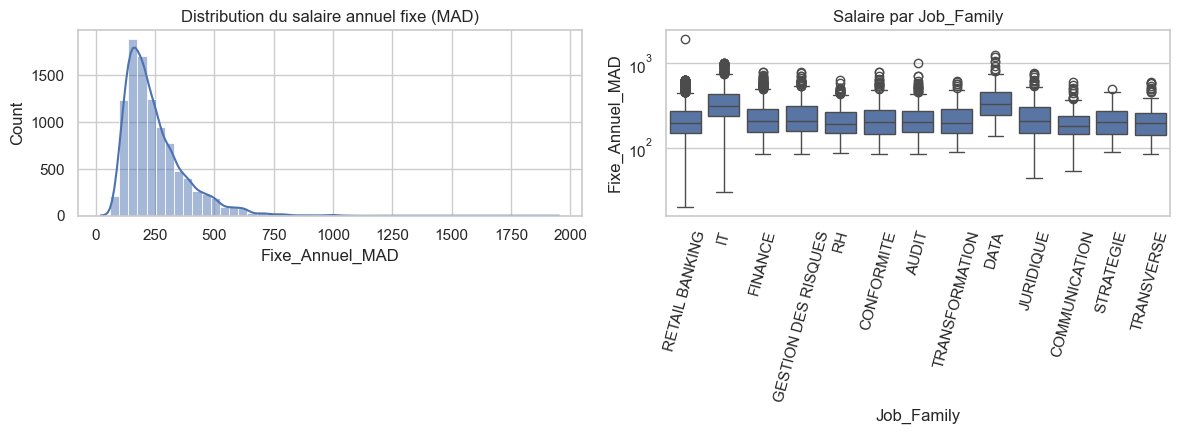

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df["Fixe_Annuel_MAD"], bins=50, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution du salaire annuel fixe (MAD)")

top_families = df["Job_Family"].value_counts().index
sns.boxplot(data=df, x="Job_Family", y="Fixe_Annuel_MAD", order=top_families, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Salaire par Job_Family")
axes[1].tick_params(axis="x", rotation=75)
plt.tight_layout()
plt.show()

**Interprétation.** Le salaire va de 20 à 1953 (MAD, en milliers) avec une médiane à 212 et une moyenne à 248 : la distribution est **étalée à droite** (quelques très hauts salaires tirent la moyenne au-dessus de la médiane), d'où l'échelle log sur les boxplots. Le boxplot par `Job_Family` montre des niveaux très différents d'un métier à l'autre (ex. `IT`/`AUDIT` vs `RETAIL BANKING`) — **implication directe** : comparer un salaire brut entre deux `Job_Family` n'a pas de sens, il faut le rapporter à un référentiel propre à son métier et son grade. C'est exactement le rôle de `CompaRatio`/`MarketRatio` (regardés juste après) : ils neutralisent cet effet Job_Family/Grade.

**Objectif du graphe suivant.** Regarder la distribution des 4 ratios de comparaison (`CompaRatio`, `RangePenetration`, `MarketRatio`, `PeerZ`) : sont-ils bien centrés autour de leur valeur "normale" (1.0 pour les ratios, 0 pour PeerZ) ? Y a-t-il des valeurs extrêmes qui sortent du lot (candidates naturelles à être détectées comme anomalies) ?

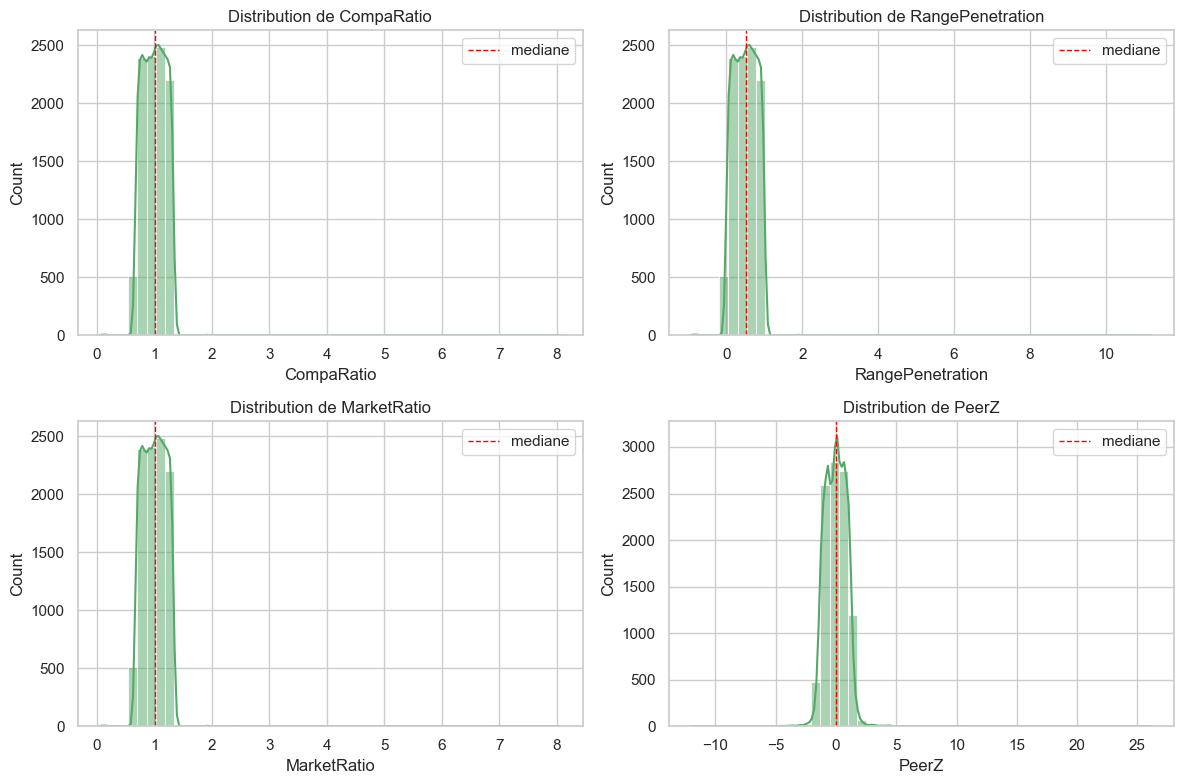

In [8]:
ratio_features = ["CompaRatio", "RangePenetration", "MarketRatio", "PeerZ"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), ratio_features):
    sns.histplot(df[col], bins=50, kde=True, ax=ax, color="#55A868")
    ax.set_title(f"Distribution de {col}")
    ax.axvline(df[col].median(), color="red", linestyle="--", linewidth=1, label="mediane")
    ax.legend()
plt.tight_layout()
plt.show()

**Interprétation.** `CompaRatio` et `MarketRatio` ont **exactement la même médiane (1.004) et le même écart-type (0.217)**, avec 27.0% des employés en dessous de 0.85 et 27.2% au-dessus de 1.15 — les deux histogrammes sont visuellement superposables, ce qui confirme le constat de la section précédente (`Mid` = `Market_Median` dans ce dataset). `RangePenetration` est centrée vers 0.50 (le milieu de bande) mais avec 84.9% des employés en dessous de 0.85 (ce chiffre n'est pas comparable à celui de CompaRatio, l'échelle de RangePenetration est différente : 0 = Min, 1 = Max de la bande) — beaucoup d'employés se situent donc dans la moitié basse de leur bande. `PeerZ` est bien centré sur 0 (médiane exacte) avec seulement 1.05% des employés à |Z|≥2 et 0.36% à |Z|≥3 : peu d'employés sont des outliers francs par rapport à leurs pairs de cohorte — la majorité des écarts observés viennent donc plutôt du positionnement vs bande/marché (CompaRatio/MarketRatio) que d'un écart entre collègues très proches (PeerZ).

**Objectif du graphe suivant.** Une matrice de corrélation pour reperer (a) les variables redondantes entre elles (qui n'apporteraient rien de plus au modele si on les garde toutes), et (b) les variables qui se comportent ensemble ou a l'inverse independamment du salaire absolu.

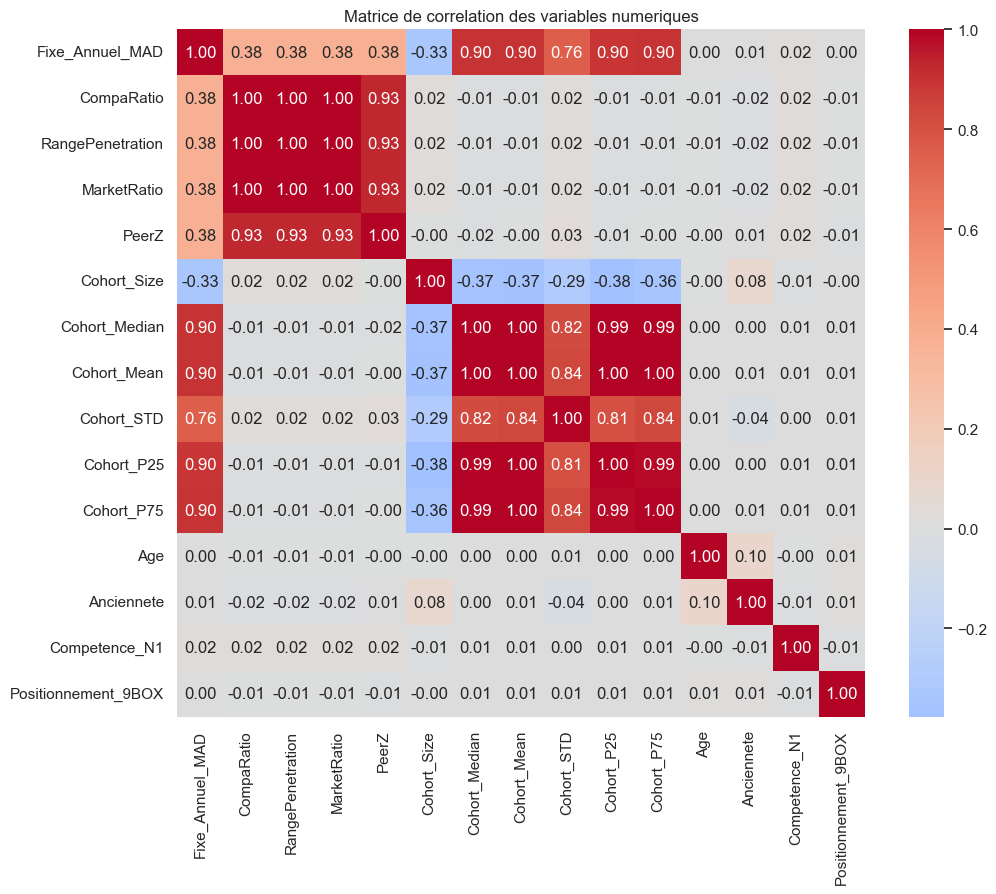

In [9]:
numeric_for_corr = [
    "Fixe_Annuel_MAD", "CompaRatio", "RangePenetration", "MarketRatio", "PeerZ",
    "Cohort_Size", "Cohort_Median", "Cohort_Mean", "Cohort_STD", "Cohort_P25", "Cohort_P75",
    "Age", "Anciennete", "Competence_N1", "Positionnement_9BOX",
]
corr = df[numeric_for_corr].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Matrice de correlation des variables numeriques")
plt.tight_layout()
plt.show()

**Interprétation.** Quelques lectures clés de cette matrice :
- `CompaRatio`, `RangePenetration` et `MarketRatio` sont corrélés à **1.00 entre eux, et même à 0.93 avec `PeerZ`** : dans ce dataset, ces 4 indicateurs (pourtant calculés de façons différentes — vs bande interne, vs marché externe, vs pairs de la cohorte) racontent en réalité **presque la même histoire**, à savoir l'écart du salaire de l'employé à ce qui est "attendu" pour son poste. C'est cohérent avec le fait que `Mid` = `Market_Median` vu plus haut, et que les cohortes sont elles-mêmes définies par Grade/Job_Family. **Implication forte pour le reste du notebook** : un modèle qui s'appuie sur ces 4 colonnes n'a en pratique qu'un seul vrai signal individuel à disposition, pas quatre — un point à garder en tête en lisant la feature importance en section 6.
- `Cohort_Median`, `Cohort_Mean`, `Cohort_P25`, `Cohort_P75` sont corrélés à **~0.90** avec `Fixe_Annuel_MAD` : logique, ce sont des agrégats calculés à partir du salaire lui-même au sein de la cohorte de l'employé — ce n'est pas un signal externe indépendant, c'est en partie une reformulation du salaire.
- `Cohort_Size` est corrélé **négativement (-0.33)** au salaire : les cohortes les plus nombreuses (ex. grades bas/métiers très peuplés comme `RETAIL BANKING`) correspondent aux salaires les plus bas — pas une anomalie, une caractéristique structurelle de l'organisation (pyramide des grades).
- `Age`, `Anciennete`, `Competence_N1`, `Positionnement_9BOX` sont **quasi non corrélés (~0.00-0.02)** avec le salaire brut : dans ce dataset, le salaire dépend presque exclusivement du couple Job_Family/Grade, pas du profil individuel de la personne. **Implication pour la détection d'anomalies** : ces variables RH ne seront probablement pas de bons signaux pour repérer un salaire anormal — elles servent plutôt à décrire le profil de la personne flaguée, pas à la flaguer.

**Objectif du graphe suivant.** Vérifier si certains groupes (métier, grade, entité, sexe, tranche d'ancienneté, hot job) ont un `CompaRatio` médian systématiquement plus haut ou plus bas que 1.0 — un signe qu'un groupe entier serait structurellement mieux/moins bien payé que sa bande, ce qui orienterait une lecture RH (équité) au-delà des cas individuels.

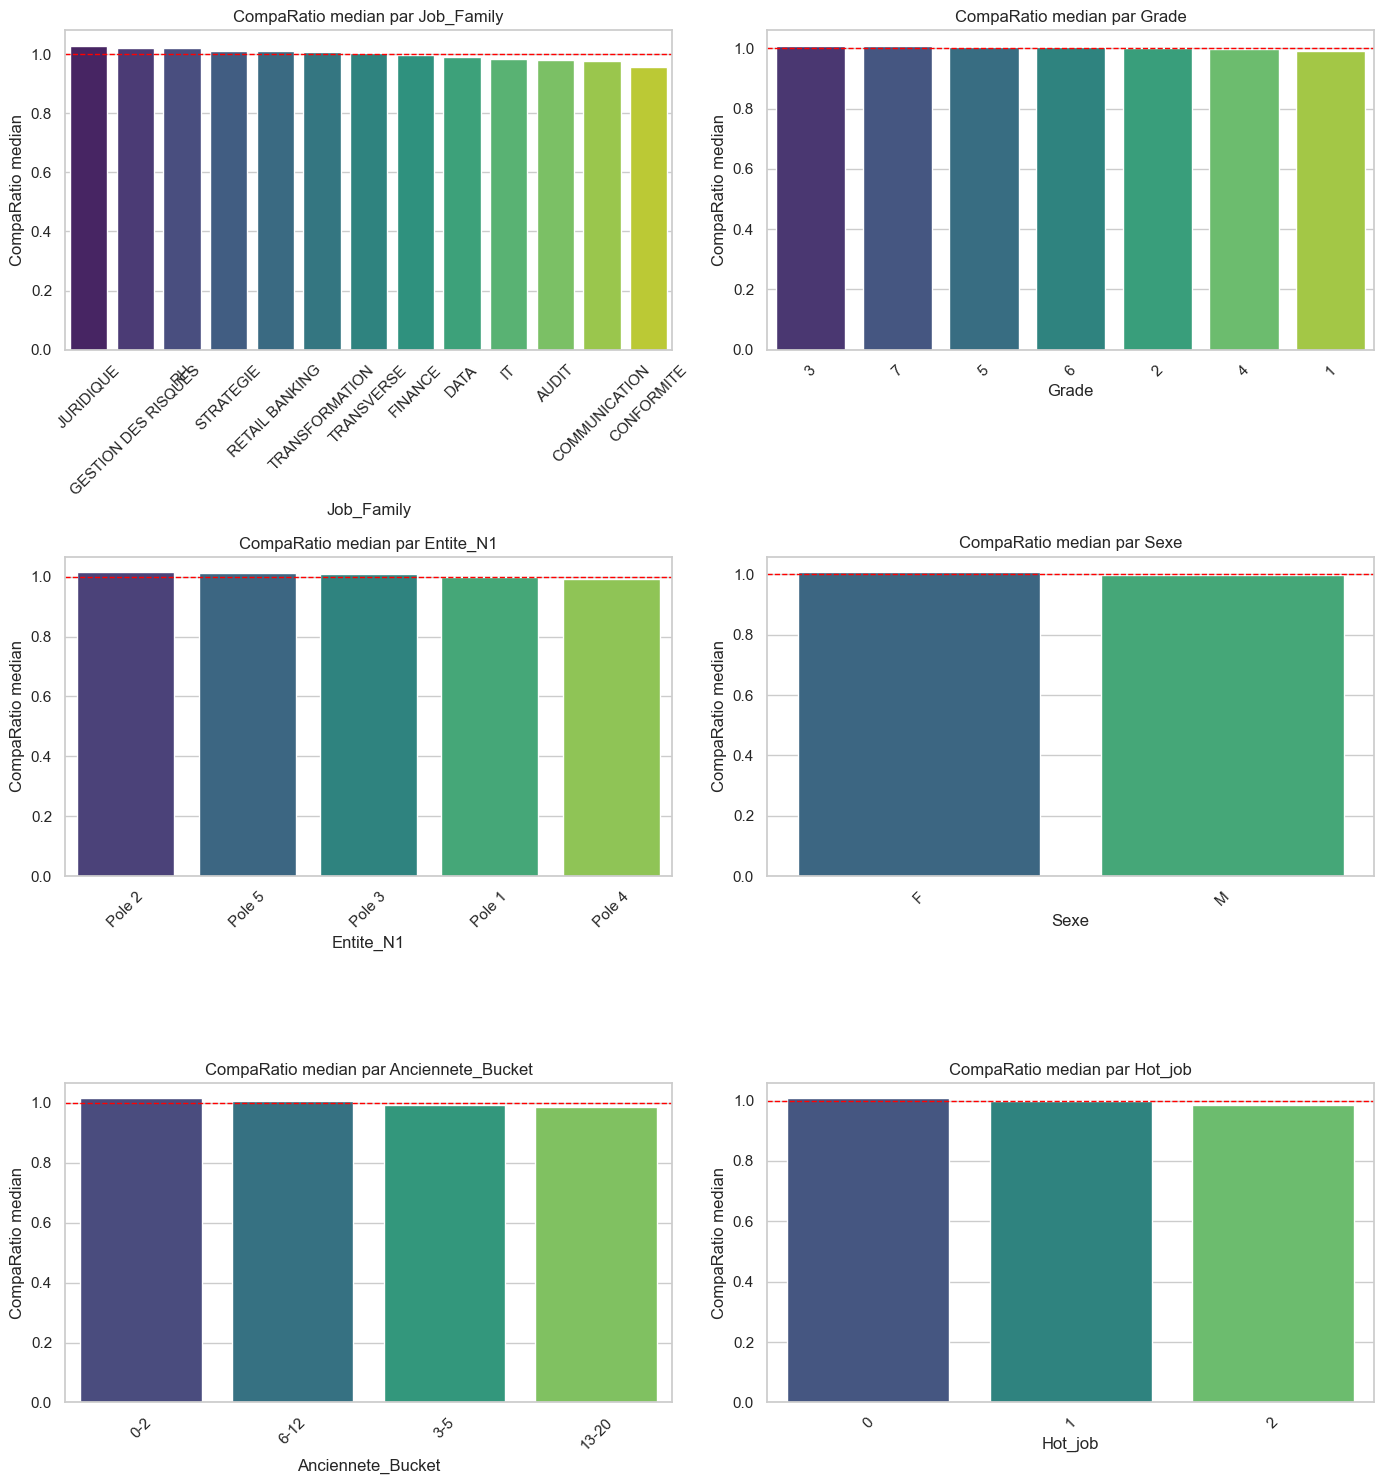

In [10]:
cat_cols = ["Job_Family", "Grade", "Entite_N1", "Sexe", "Anciennete_Bucket", "Hot_job"]

fig, axes = plt.subplots(3, 2, figsize=(14, 15))
for ax, col in zip(axes.ravel(), cat_cols):
    med_compa = df.groupby(col)["CompaRatio"].median().sort_values(ascending=False)
    sns.barplot(x=med_compa.index.astype(str), y=med_compa.values, hue=med_compa.index.astype(str),
                palette="viridis", legend=False, ax=ax)
    ax.axhline(1.0, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"CompaRatio median par {col}")
    ax.set_ylabel("CompaRatio median")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Interprétation.** Les écarts entre groupes sont **faibles** (tous les médians restent entre 0.96 et 1.03, à comparer à la référence 1.0) :
- Par `Job_Family` : de `CONFORMITE` (0.958, le plus bas) à `JURIDIQUE` (1.029, le plus haut) — moins de 4% d'écart entre le métier le mieux et le moins bien positionné vs sa bande.
- Par `Sexe` : `F` = 1.008 vs `M` = 0.999 — les femmes sont ici très légèrement **au-dessus** de leur bande par rapport aux hommes, pas en-dessous. Il n'y a donc pas de signal d'écart de rémunération défavorable aux femmes dans ce jeu de données (à confirmer avec l'analyse dédiée `gender_gap_analysis` du projet, plus rigoureuse sur ce sujet).
- Par `Anciennete_Bucket` : les plus jeunes dans le poste (0-2 ans, 1.015) sont legerement au-dessus des plus anciens (13-20 ans, 0.987) — pas d'effet flagrant de sous-paiement des nouveaux arrivants.

**Implication** : il n'y a pas de biais structurel massif d'un groupe entier — les anomalies qu'on va détecter seront donc probablement des cas **individuels** dispersés dans les groupes, plutôt que des groupes entiers mal positionnés.

## 4. Detection d'anomalies non supervisee

On construit une matrice de features (ratios de comparaison marche + stats de cohorte + profil RH),
standardisee/encodee, puis on entraine trois familles de detecteurs d'outliers :
- **Isolation Forest** (deja utilise ailleurs dans le projet, robuste en grande dimension)
- **Local Outlier Factor** (densite locale, detecte les outliers "relatifs a leur voisinage")
- **One-Class SVM** (frontiere de decision globale)

Chacun est parametre avec `contamination=0.05` (hypothese : ~5% de la population est anormale),
hypothese explicite a challenger metier, pas une verite mesuree.

In [11]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA

numeric_features = [
    "CompaRatio", "RangePenetration", "MarketRatio", "PeerZ",
    "Cohort_Size", "Cohort_Median", "Cohort_Mean", "Cohort_STD", "Cohort_P25", "Cohort_P75",
    "Age", "Anciennete", "Competence_N1", "Positionnement_9BOX",
]
categorical_features = ["Grade", "Job_Family", "Entite_N1", "Sexe", "Hot_job", "Anciennete_Bucket"]

feature_cols = numeric_features + categorical_features
X_raw = df[feature_cols].copy()
for c in categorical_features:
    X_raw[c] = X_raw[c].astype(str)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])
X = preprocessor.fit_transform(X_raw)
feature_names = preprocessor.get_feature_names_out()
print("Matrice de features :", X.shape)

Matrice de features : (10000, 48)


**Interprétation.** 48 colonnes en sortie : 14 numériques standardisées + 34 colonnes one-hot (7 `Grade` + 13 `Job_Family` + 5 `Entite_N1` + 2 `Sexe` + 3 `Hot_job` + 4 `Anciennete_Bucket`). C'est cette matrice, et elle seule, qui est fournie aux 3 détecteurs ci-dessous — aucun ne voit `Matricule`, `Job_Title`, ni bien sûr les colonnes de scoring de règles qu'on a supprimées en section 2.

In [12]:
CONTAMINATION = 0.05

iso = IsolationForest(n_estimators=300, contamination=CONTAMINATION, random_state=RANDOM_STATE)
iso_pred = iso.fit_predict(X)          # -1 = anomalie, 1 = normal
iso_score = -iso.score_samples(X)      # plus haut = plus anormal

lof = LocalOutlierFactor(n_neighbors=35, contamination=CONTAMINATION)
lof_pred = lof.fit_predict(X)
lof_score = -lof.negative_outlier_factor_

ocsvm = OneClassSVM(nu=CONTAMINATION, kernel="rbf", gamma="scale")
ocsvm_pred = ocsvm.fit_predict(X)
ocsvm_score = -ocsvm.decision_function(X)

df["IsoForest_Anomalie"] = (iso_pred == -1).astype(int)
df["LOF_Anomalie"] = (lof_pred == -1).astype(int)
df["OCSVM_Anomalie"] = (ocsvm_pred == -1).astype(int)
df["IsoForest_Score"] = iso_score

for name, col in [("Isolation Forest", "IsoForest_Anomalie"), ("Local Outlier Factor", "LOF_Anomalie"),
                   ("One-Class SVM", "OCSVM_Anomalie")]:
    print(f"{name:22s} : {df[col].sum()} anomalies detectees sur {len(df)} ({df[col].mean():.1%})")

Isolation Forest       : 500 anomalies detectees sur 10000 (5.0%)
Local Outlier Factor   : 500 anomalies detectees sur 10000 (5.0%)
One-Class SVM          : 507 anomalies detectees sur 10000 (5.1%)


**Interprétation.** Isolation Forest et LOF trouvent tous deux exactement **500 anomalies (5.0%)** : c'est attendu, ces deux modèles utilisent `contamination=0.05` comme un **quantile exact** de leur score — ils sont donc mécaniquement calés sur 5%. One-Class SVM en trouve **507 (5.1%)** : son paramètre `nu` est une *borne* sur la fraction de points hors-frontière, pas un quantile forcé, d'où le léger écart. **Point important à retenir** : ce n'est pas parce que les 3 modèles trouvent ~5% chacun qu'ils sont d'accord sur les **mêmes personnes** — c'est justement ce qu'on va vérifier dans la section suivante.

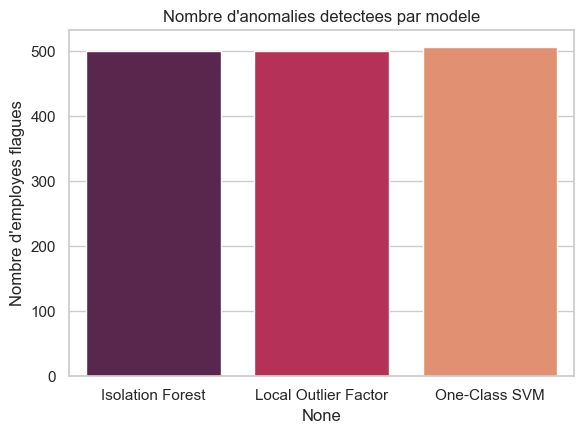

In [13]:
fig, ax = plt.subplots(figsize=(6, 4.5))
counts = df[["IsoForest_Anomalie", "LOF_Anomalie", "OCSVM_Anomalie"]].sum()
counts.index = ["Isolation Forest", "Local Outlier Factor", "One-Class SVM"]
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette="rocket", legend=False, ax=ax)
ax.set_title("Nombre d'anomalies detectees par modele")
ax.set_ylabel("Nombre d'employes flagues")
plt.tight_layout()
plt.show()

**Interprétation.** Visuellement les 3 barres sont quasi identiques (~500-507) — ce graphe confirme juste en un coup d'oeil ce qui vient d'être imprimé. Il ne dit rien sur l'**accord** entre modèles : deux modèles peuvent flaguer 500 personnes chacun sans flaguer les 500 mêmes. C'est l'objet des deux graphes suivants (indice de Jaccard, puis projection PCA).

## 5. Consensus entre modeles et visualisation

In [14]:
df["Nb_Modeles_Accord"] = df[["IsoForest_Anomalie", "LOF_Anomalie", "OCSVM_Anomalie"]].sum(axis=1)
df["Anomalie_Consensus"] = (df["Nb_Modeles_Accord"] >= 2).astype(int)

print(df["Nb_Modeles_Accord"].value_counts().sort_index())
print()
print(f"Anomalies en consensus (>=2 modeles sur 3) : {df['Anomalie_Consensus'].sum()} "
      f"({df['Anomalie_Consensus'].mean():.1%})")

Nb_Modeles_Accord
0    9006
1     577
2     321
3      96
Name: count, dtype: int64

Anomalies en consensus (>=2 modeles sur 3) : 417 (4.2%)


**Interprétation.** Sur 10 000 employés : 9006 ne sont flagués par **aucun** modèle, 577 par **un seul**, 321 par **deux**, et seulement 96 par **les trois**. Le fait que 577 employés (bien plus que les 96 en accord total) ne soient flagués que par un seul algorithme confirme que **les 3 détecteurs ne regardent pas exactement la même chose** malgré des totaux individuels proches (vu juste avant). Le seuil retenu ici — consensus ≥ 2 modèles sur 3 — aboutit à **417 anomalies (4.2%)** : un compromis qui écarte le bruit propre à un seul algorithme tout en ne retenant pas seulement les 96 cas où les 3 sont unanimes (trop restrictif).

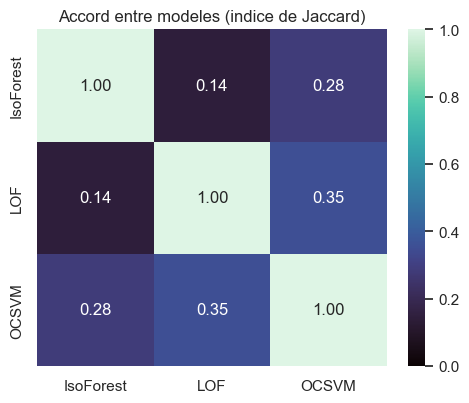

In [15]:
jaccard = pd.DataFrame(index=["IsoForest", "LOF", "OCSVM"], columns=["IsoForest", "LOF", "OCSVM"], dtype=float)
cols = {"IsoForest": "IsoForest_Anomalie", "LOF": "LOF_Anomalie", "OCSVM": "OCSVM_Anomalie"}
for a, ca in cols.items():
    for b, cb in cols.items():
        inter = ((df[ca] == 1) & (df[cb] == 1)).sum()
        union = ((df[ca] == 1) | (df[cb] == 1)).sum()
        jaccard.loc[a, b] = inter / union if union else np.nan

plt.figure(figsize=(5, 4.2))
sns.heatmap(jaccard, annot=True, fmt=".2f", cmap="mako", vmin=0, vmax=1)
plt.title("Accord entre modeles (indice de Jaccard)")
plt.tight_layout()
plt.show()

**Interprétation.** Les indices de Jaccard (intersection/union des personnes flaguées) sont **bas** : IsoForest∩LOF = 0.14, IsoForest∩OCSVM = 0.28, LOF∩OCSVM = 0.35. Un accord parfait donnerait 1.00 partout (hors diagonale) ; ici on est loin en dessous, ce qui **quantifie** l'observation de la cellule précédente : chaque algorithme capture une notion différente d' "anormalité" (isolement par partitionnement pour IsoForest, densité locale pour LOF, frontière globale pour OCSVM). **Implication méthodologique** : se fier à un seul de ces modèles reviendrait à faire un choix arbitraire de définition de l'anomalie ; le consensus (≥2/3) est une façon de rester robuste à ce choix.

**Objectif du graphe suivant.** Projeter les 48 dimensions de la matrice de features sur un plan 2D (PCA) pour voir, visuellement, si les employés en anomalie de consensus se distinguent geometriquement du reste du nuage de points.

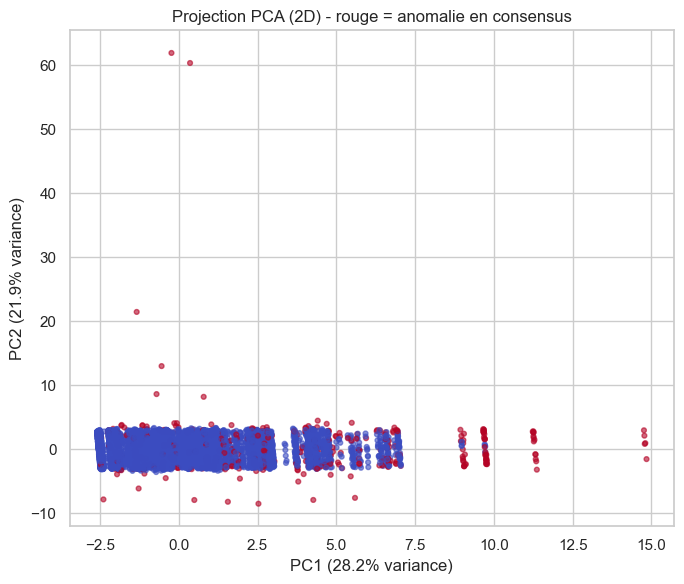

In [16]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X)

plt.figure(figsize=(7, 6))
sc = plt.scatter(coords[:, 0], coords[:, 1], c=df["Anomalie_Consensus"], cmap="coolwarm",
                  s=12, alpha=0.6)
plt.title("Projection PCA (2D) - rouge = anomalie en consensus")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.tight_layout()
plt.show()

**Interprétation.** Les 2 premiers axes ne résument que **50% de la variance totale** (28.2% + 21.9%) : une bonne partie de l'information des 48 colonnes originales est donc perdue sur ce plan 2D, la séparation visuelle est forcément partielle/approximative, pas une preuve définitive. On observe malgré tout que les points rouges (consensus) ont tendance à se situer plutôt en périphérie du nuage bleu plutôt qu'au centre — cohérent avec la logique même de la détection d'outliers (les anomalies sont, par définition, plus "isolées") — mais un certain nombre de points rouges restent mélangés au nuage bleu : cette projection 2D ne permet pas de séparer parfaitement les deux groupes à l'oeil nu, ce qui est normal avec seulement 50% de variance expliquée.

In [17]:
top_anomalies = df.sort_values("IsoForest_Score", ascending=False).head(15)
top_anomalies[["Matricule", "Job_Family", "Grade", "Fixe_Annuel_MAD", "CompaRatio",
               "MarketRatio", "PeerZ", "Nb_Modeles_Accord"]]

,Matricule,Job_Family,Grade,Fixe_Annuel_MAD,CompaRatio,MarketRatio,PeerZ,Nb_Modeles_Accord
7683,Mat07684,CONFORMITE,1,456.08,0.749910,0.749910,-0.989646,3
1837,Mat01838,CONFORMITE,1,803.03,1.320382,1.320382,0.937219,3
8669,Mat08670,JURIDIQUE,1,744.83,1.224687,1.224687,2.505239,3
9782,Mat09783,IT,1,525.70,0.689045,0.689045,-2.416209,2
2467,Mat02468,IT,1,971.63,1.273534,1.273534,1.078990,2
1956,Mat01957,CONFORMITE,1,473.52,0.778585,0.778585,-0.892789,2
6714,Mat06715,DATA,2,932.55,1.255807,1.255807,0.846491,3
8502,Mat08503,IT,1,718.64,0.941935,0.941935,-1.176326,3
3214,Mat03215,IT,1,524.91,0.688010,0.688010,-1.240572,2
4313,Mat04314,IT,1,1012.00,1.326448,1.326448,1.267300,2


**Interprétation.** Le classement par score Isolation Forest fait ressortir surtout des `Grade` 1 (les plus hauts grades) chez `IT`, `CONFORMITE`, `JURIDIQUE`, `DATA` — ces cohortes de haut grade sont aussi les plus petites en effectif (cf. `Cohort_Size` faible), donc statistiquement plus faciles à "isoler". On voit un mélange de profils **sur-payés** (ex. Mat04314 : CompaRatio 1.33, PeerZ +1.27) et **sous-payés** (ex. Mat09783 : CompaRatio 0.69, PeerZ -2.42) — la détection n'est pas biaisée dans un seul sens. La colonne `Nb_Modeles_Accord` montre que la plupart de ce top 15 sont en accord 2/3 ou 3/3, ce qui renforce la confiance sur ces cas précis.

## 6. Classification interpretable (surrogate model)

Les detecteurs non supervises ci-dessus (en particulier Isolation Forest) ne fournissent pas
directement une importance de variables lisible. On entraine donc un **classifieur supervise**
(Random Forest) a reproduire le label `Anomalie_Consensus` a partir des memes features : son role
n'est pas de generaliser a de nouvelles donnees (le label qu'il apprend vient du consensus
non supervise, pas d'une verite terrain), mais de servir de **modele-substitut interpretable** pour
lire clairement quelles variables caracterisent les profils flagues comme anormaux, et de pouvoir
re-scorer rapidement un nouvel employe sans relancer les 3 detecteurs.

In [18]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, roc_auc_score, f1_score,
)
from sklearn.inspection import permutation_importance
import joblib

y = df["Anomalie_Consensus"]
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_raw, y, df.index, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

In [19]:
surrogate_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                    random_state=RANDOM_STATE, n_jobs=-1)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_res = cross_validate(surrogate_pipe, X_train, y_train, cv=cv,
                         scoring=["accuracy", "precision", "recall", "f1", "roc_auc"])
for m in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    print(f"{m:10s} : {cv_res['test_' + m].mean():.3f}")

surrogate_pipe.fit(X_train, y_train)

accuracy   : 0.966
precision  : 0.827
recall     : 0.233
f1         : 0.361
roc_auc    : 0.962


,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


**Interprétation.** En validation croisée : accuracy 0.966 mais **recall seulement 0.233** pour un F1 de 0.361, alors que le ROC-AUC est très élevé (0.962). C'est un schéma classique en situation déséquilibrée (ici ~4.2% de positifs) : le modèle **classe très bien par rang** (il sait ordonner les employés du plus au moins suspect, d'où l'AUC élevé) mais le seuil par défaut de 0.5 est trop conservateur et le fait manquer une majorité des cas positifs (recall bas). L'accuracy élevée est trompeuse ici : un modèle qui ne prédirait jamais "Anomalie" aurait déjà ~96% d'accuracy vu le déséquilibre des classes. Si l'objectif métier est de ne manquer aucun cas suspect, il faudrait abaisser le seuil de décision (voir la courbe ROC ci-dessous pour arbitrer ce compromis précision/rappel).

              precision    recall  f1-score   support

      Normal       0.97      1.00      0.98      2396
    Anomalie       0.91      0.29      0.44       104

    accuracy                           0.97      2500
   macro avg       0.94      0.64      0.71      2500
weighted avg       0.97      0.97      0.96      2500



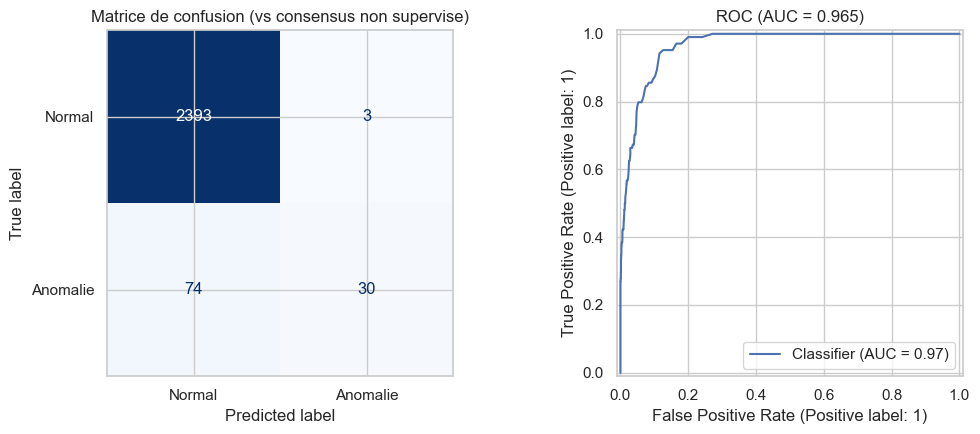

In [20]:
y_pred = surrogate_pipe.predict(X_test)
y_proba = surrogate_pipe.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["Normal", "Anomalie"]))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Normal", "Anomalie"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Matrice de confusion (vs consensus non supervise)")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title(f"ROC (AUC = {roc_auc_score(y_test, y_proba):.3f})")
plt.tight_layout()
plt.show()

**Interprétation.** Sur le jeu de test (2500 employés, 104 anomalies de consensus) : la matrice de confusion montre 2393 vrais négatifs, seulement 3 faux positifs, mais 74 faux négatifs pour 30 vrais positifs. Autrement dit : **precision 0.91** (quand le modèle dit "Anomalie", il a raison 9 fois sur 10 — très peu de fausses alertes) mais **recall 0.29** (il ne retrouve que 30 des 104 cas que le consensus non supervisé avait flagués — il en rate 71%). La courbe ROC (AUC = 0.965) confirme que le modèle **classe bien par rang** malgré ce recall faible au seuil 0.5 : en pratique, pour un usage RH, on pourrait trier tous les employés par `predict_proba` décroissante et regarder le haut de la liste plutôt que de se fier au seuil 0.5 par défaut, afin de capter plus de vrais positifs (au prix d'un peu plus de faux positifs).

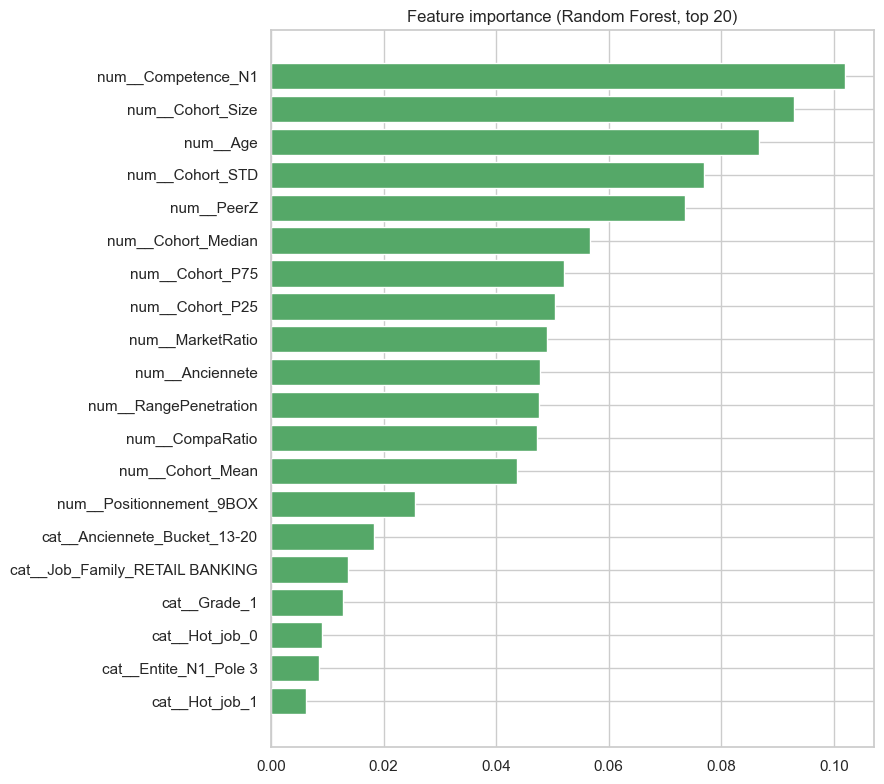

In [21]:
surrogate_feature_names = surrogate_pipe.named_steps["prep"].get_feature_names_out()
rf = surrogate_pipe.named_steps["clf"]

native_imp = pd.Series(rf.feature_importances_, index=surrogate_feature_names) \
    .sort_values(ascending=False).head(20)

plt.figure(figsize=(9, 8))
plt.barh(native_imp.index[::-1], native_imp.values[::-1], color="#55A868")
plt.title("Feature importance (Random Forest, top 20)")
plt.tight_layout()
plt.show()

**Interprétation — à lire avec prudence.** Ce classement (`Competence_N1`, `Cohort_Size`, `Age`, `Cohort_STD`, `PeerZ` en tête) est l'importance **native** de Random Forest (basée sur la réduction d'impureté à chaque split). Cette mesure est connue pour **sur-valoriser les variables continues à forte cardinalité** (beaucoup de valeurs distinctes possibles, comme `Competence_N1` ou `Age`) par rapport aux variables catégorielles encodées en one-hot ou aux variables plus "grossières" — ce n'est pas un défaut de cette analyse, c'est une limite mathématique connue de cette métrique. **C'est pourquoi on calcule aussi la permutation importance ci-dessous**, qui mesure directement l'impact sur la performance réelle (pas un proxy interne à l'arbre) et est plus fiable pour comparer des variables de nature différente.

**Objectif du graphe suivant.** Recalculer une feature importance plus fiable (permutation importance) : on mélange aléatoirement chaque variable une à une et on regarde de combien le F1 du modèle se dégrade — plus la dégradation est grande, plus la variable est réellement utile au modèle pour repérer les anomalies.

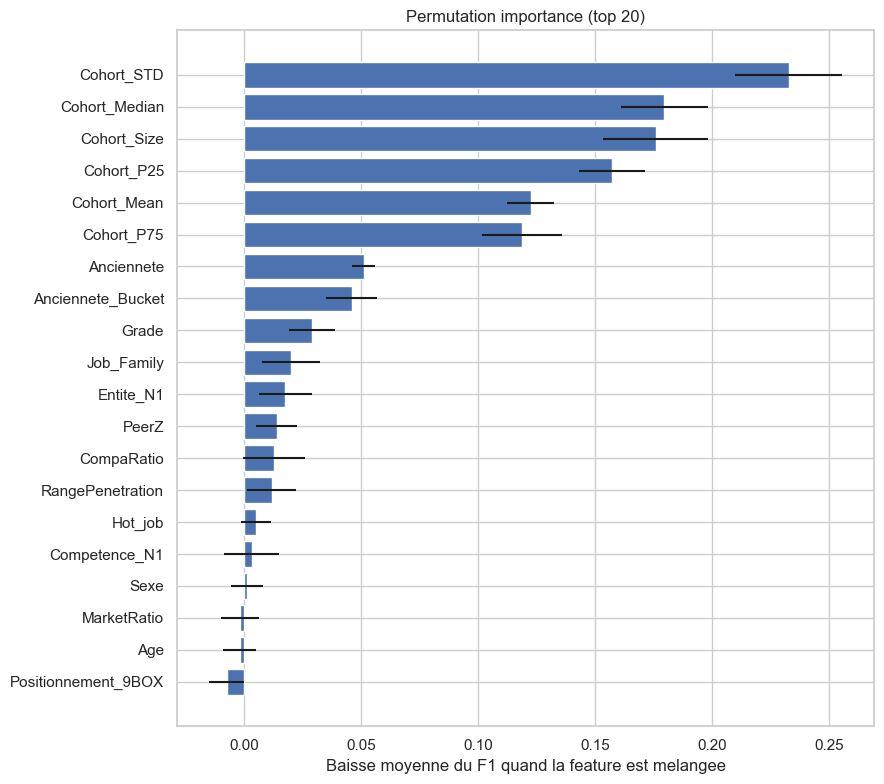

In [22]:
# permutation_importance permute les colonnes EN ENTREE du pipeline (donc les colonnes
# d'origine avant one-hot encoding), pas les colonnes transformees : les noms a utiliser sont
# ceux de X_test (feature_cols), pas surrogate_feature_names (qui viennent apres l'encodage).
perm = permutation_importance(surrogate_pipe, X_test, y_test, n_repeats=15,
                               random_state=RANDOM_STATE, n_jobs=-1, scoring="f1")
perm_imp = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False).head(20)

plt.figure(figsize=(9, 8))
plt.barh(perm_imp["feature"][::-1], perm_imp["importance_mean"][::-1],
         xerr=perm_imp["importance_std"][::-1], color="#4C72B0")
plt.title("Permutation importance (top 20)")
plt.xlabel("Baisse moyenne du F1 quand la feature est melangee")
plt.tight_layout()
plt.show()

**Interprétation — le résultat le plus important du notebook.** Ici, ce sont les statistiques de **cohorte** qui dominent largement : `Cohort_STD` (0.233), `Cohort_Median` (0.179), `Cohort_Size` (0.176), `Cohort_P25` (0.157), `Cohort_Mean` (0.122) — alors que les ratios individuels `CompaRatio` (0.013), `PeerZ` (0.014), `MarketRatio` (-0.002) et `RangePenetration` (0.012) arrivent **très loin derrière**, quasiment sans effet mesurable.

Ce que ça implique concrètement : le fait qu'un employé soit flagué "anomalie" par le pipeline non supervisé dépend **beaucoup plus de la cohorte à laquelle il appartient** (une cohorte petite et/ou avec un écart-type de salaire élevé) **que de son propre écart individuel** à sa bande/son marché/ses pairs. C'est cohérent avec l'observation de la section 3 (Isolation Forest isole plus facilement les points dans des cohortes peu peuplées) et avec la matrice de corrélation (les 4 ratios individuels étaient quasi redondants entre eux, à 0.93-1.00 — le modèle a donc peu de marge pour s'appuyer dessus, alors que les 5 statistiques de cohorte sont des variables numériques distinctes qui varient beaucoup d'une cohorte à l'autre).

**Limite à ne pas ignorer** : ce n'est probablement pas ce qu'on attendrait métier (on voudrait que ce soit avant tout l'écart individuel qui déclenche le flag, pas la taille/dispersion de son groupe de comparaison). Une piste d'amélioration serait de relancer la détection **sans** les colonnes `Cohort_*` (garder seulement `CompaRatio`/`PeerZ`/`RangePenetration` + profil RH) pour voir si les anomalies détectées se recentrent davantage sur l'écart individuel — voir la section Conclusion.

## 7. Sauvegarde des resultats

In [23]:
joblib.dump(surrogate_pipe, MODEL_DIR / "model_anomalie.joblib")
joblib.dump(preprocessor, MODEL_DIR / "preprocessor.joblib")

output_cols = [
    "Matricule", "Job_Family", "Job_Title", "Grade", "Entite_N1", "Fixe_Annuel_MAD",
    "Min", "Mid", "Max", "Market_Median", "CompaRatio", "RangePenetration", "MarketRatio",
    "Cohort_Key", "Cohort_Size", "PeerZ",
    "IsoForest_Anomalie", "LOF_Anomalie", "OCSVM_Anomalie", "Nb_Modeles_Accord", "Anomalie_Consensus",
    "IsoForest_Score",
]
df[output_cols].sort_values("IsoForest_Score", ascending=False).to_csv(
    OUTPUT_DIR / "anomalies_detectees.csv", index=False
)

print("Modele surrogate sauvegarde : model_anomalie.joblib")
print("Preprocesseur sauvegarde    : preprocessor.joblib")
print("Resultats sauvegardes       : anomalies_detectees.csv")

Modele surrogate sauvegarde : model_anomalie.joblib
Preprocesseur sauvegarde    : preprocessor.joblib
Resultats sauvegardes       : anomalies_detectees.csv


## Conclusion

In [24]:
summary = f"""=== SYNTHESE ===
Population analysee            : {len(df)} employes (avec correspondance bande/marche complete)
Contamination fixee a priori   : {CONTAMINATION:.0%}
Anomalies Isolation Forest     : {df['IsoForest_Anomalie'].sum()}
Anomalies Local Outlier Factor : {df['LOF_Anomalie'].sum()}
Anomalies One-Class SVM        : {df['OCSVM_Anomalie'].sum()}
Anomalies en consensus (>=2/3) : {df['Anomalie_Consensus'].sum()} ({df['Anomalie_Consensus'].mean():.1%})

Modele surrogate (Random Forest) - performance vs le consensus non supervise :
  F1 (test)      : {f1_score(y_test, y_pred):.3f}
  ROC-AUC (test) : {roc_auc_score(y_test, y_proba):.3f}

Top 5 features qui caracterisent le plus les anomalies (permutation importance) :
{perm_imp.head(5)[["feature", "importance_mean"]].to_string(index=False)}

Limites :
- Aucune etiquette de verite terrain n'existe dans les donnees brutes : Isolation Forest/LOF/OCSVM
  reposent sur l'hypothese qu'environ {CONTAMINATION:.0%} des employes sont des anomalies. Ce chiffre
  est une hypothese de depart a valider avec les equipes RH/Remuneration, pas une mesure.
- Le modele surrogate (Random Forest) est entraine pour EXPLIQUER le consensus non supervise, pas
  pour predire une verite independante : ses bonnes performances refletent la coherence interne du
  pipeline, pas une validation externe.
- La feature importance (section 6) montre que ce sont surtout les statistiques de COHORTE
  (Cohort_STD, Cohort_Median, Cohort_Size...) qui pilotent le flag d'anomalie, beaucoup plus que
  l'ecart individuel de l'employe (CompaRatio/PeerZ/MarketRatio, quasi sans effet mesurable). Une
  piste d'amelioration : relancer la detection sans les colonnes Cohort_* pour verifier si les
  anomalies se recentrent davantage sur l'ecart individuel, qui est probablement ce qu'on veut
  detecter en priorite d'un point de vue metier.
- CompaRatio, RangePenetration, MarketRatio et PeerZ sont correles entre 0.93 et 1.00 dans ce
  dataset (Mid = Market_Median pour toutes les bandes) : ils apportent une information quasi
  redondante, pas 4 signaux independants.
- Donnees mono-periode (une seule Date_Effet_Paie) : aucune dimension temporelle testee.
- Les employes sans correspondance Job_Family/Grade dans bands.csv ou market.csv ont ete ecartes de
  l'analyse (voir section 2).
"""
print(summary)

=== SYNTHESE ===
Population analysee            : 10000 employes (avec correspondance bande/marche complete)
Contamination fixee a priori   : 5%
Anomalies Isolation Forest     : 500
Anomalies Local Outlier Factor : 500
Anomalies One-Class SVM        : 507
Anomalies en consensus (>=2/3) : 417 (4.2%)

Modele surrogate (Random Forest) - performance vs le consensus non supervise :
  F1 (test)      : 0.438
  ROC-AUC (test) : 0.965

Top 5 features qui caracterisent le plus les anomalies (permutation importance) :
      feature  importance_mean
   Cohort_STD         0.232628
Cohort_Median         0.179451
  Cohort_Size         0.175782
   Cohort_P25         0.157361
  Cohort_Mean         0.122439

Limites :
- Aucune etiquette de verite terrain n'existe dans les donnees brutes : Isolation Forest/LOF/OCSVM
  reposent sur l'hypothese qu'environ 5% des employes sont des anomalies. Ce chiffre
  est une hypothese de depart a valider avec les equipes RH/Remuneration, pas une mesure.
- Le modele surr